In [5]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

root = Path.cwd()
animals = pd.read_csv(root / "Data" / "AnimalList.csv")

In [11]:
records = []

for animal_row in animals.itertuples():
    animal_id = animal_row.AnimalID
    genotype = animal_row.Genotype
    animal_folder = root / "Data" / str(animal_id)
    
    # Sort files by date to determine session order
    csv_files = sorted(animal_folder.glob("*.csv"))
    
    for session_num, csv_file in enumerate(csv_files, start=1):
        df = pd.read_csv(csv_file)
        
        total = len(df)
        rewarded = df["reward"].notna().sum()
        performance = rewarded / total
        
        records.append({
            "animal_id": animal_id,
            "genotype": genotype,
            "session": session_num,
            "performance": performance
        })

summary = pd.DataFrame(records)
summary.head()

,animal_id,genotype,session,performance
0,317,WT,1,0.469983
1,317,WT,2,0.551173
2,317,WT,3,0.684278
3,354,WT,1,0.547731
4,354,WT,2,0.622605


In [12]:
avg = summary.groupby(["session", "genotype"])["performance"].mean().reset_index()
avg

,session,genotype,performance
0,1,HET,0.670937
1,1,WT,0.501334
2,2,HET,0.775370
3,2,WT,0.557037
4,3,HET,0.800757
5,3,WT,0.621124


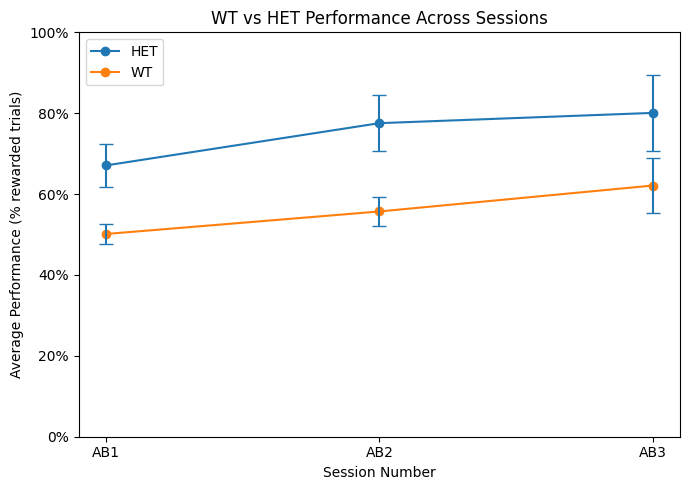

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

for genotype, group in avg.groupby("genotype"):
    # Calculate standard error per session per genotype
    err = summary.groupby(["session", "genotype"])["performance"].sem().reset_index()
    err_vals = err[err["genotype"] == genotype]["performance"].values
    
    ax.plot(group["session"], group["performance"], marker="o", label=genotype)
    ax.errorbar(group["session"], group["performance"], yerr=err_vals, fmt="none", capsize=5)

ax.set_xlabel("Session Number")
ax.set_ylabel("Average Performance (% rewarded trials)")
ax.set_title("WT vs HET Performance Across Sessions")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["AB1", "AB2", "AB3"])
ax.set_ylim(0, 1)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig(root / "performance_by_genotype.png", dpi=150)
plt.show()